<a href="https://colab.research.google.com/github/marieee005/EstadisticaVerano2026/blob/main/ProyectoU4/U4_Proyecto_Integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Base de datos del experimento

**¿El tipo de dispositivo (laptop, celular o tableta) influye en el tiempo que tarda una persona en escribir un mismo texto??**

La siguiente tabla contiene los tiempos obtenidos por los 10 participantes en cada uno de los tres dispositivos. El tiempo se registró en segundos.


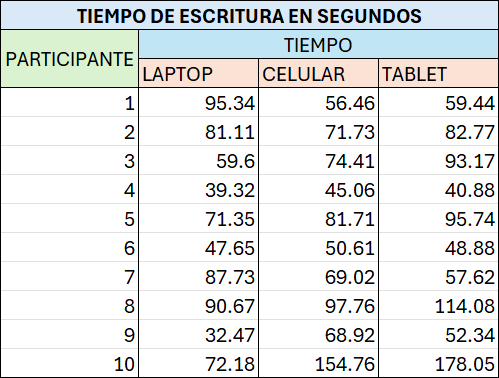

In [171]:
import pandas as pd
from io import StringIO

datos = '''
Participante,Tiempo_Segundos,Dispositivo
P1,95.34,Laptop
P1,56.46,Celular
P1,59.44,Tablet
P2,81.11,Laptop
P2,71.73,Celular
P2,82.77,Tablet
P3,59.60,Laptop
P3,74.41,Celular
P3,93.17,Tablet
P4,39.32,Laptop
P4,45.06,Celular
P4,40.88,Tablet
P5,71.35,Laptop
P5,81.71,Celular
P5,95.74,Tablet
P6,47.65,Laptop
P6,50.61,Celular
P6,48.88,Tablet
P7,87.73,Laptop
P7,69.02,Celular
P7,57.62,Tablet
P8,90.67,Laptop
P8,97.76,Celular
P8,114.08,Tablet
P9,32.47,Laptop
P9,68.92,Celular
P9,52.34,Tablet
P10,72.18,Laptop
P10,154.76,Celular
P10,178.05,Tablet
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Participante,Tiempo_Segundos,Dispositivo
0,P1,95.34,Laptop
1,P1,56.46,Celular
2,P1,59.44,Tablet
3,P2,81.11,Laptop
4,P2,71.73,Celular
5,P2,82.77,Tablet
6,P3,59.60,Laptop
7,P3,74.41,Celular
8,P3,93.17,Tablet
9,P4,39.32,Laptop


In [172]:
# Estadísticos descriptivos por dispositivo

estadisticos = df.groupby("Dispositivo")["Tiempo_Segundos"].agg(
    cantidad="count",
    media="mean",
    mediana="median",
    desviacion_estandar="std",
    minimo="min",
    maximo="max"
)

estadisticos.round(2)

,cantidad,media,mediana,desviacion_estandar,minimo,maximo
Dispositivo,,,,,,
Celular,10,77.04,70.38,31.27,45.06,154.76
Laptop,10,67.74,71.76,22.16,32.47,95.34
Tablet,10,82.30,71.10,41.28,40.88,178.05


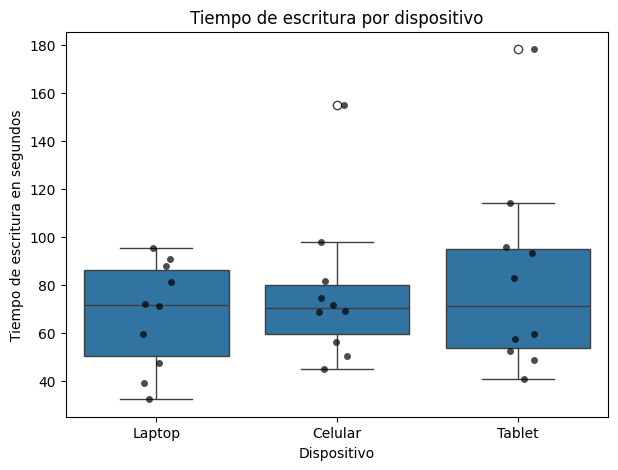

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Dispositivo",
    y="Tiempo_Segundos"
)

sns.stripplot(
    data=df,
    x="Dispositivo",
    y="Tiempo_Segundos",
    color="black",
    alpha=0.7
)

plt.title("Tiempo de escritura por dispositivo")
plt.xlabel("Dispositivo")
plt.ylabel("Tiempo de escritura en segundos")
plt.show()

In [174]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: El tiempo promedio es igual en los tres dispositivos.
# H1: Al menos un dispositivo presenta un tiempo promedio diferente.

modelo = ols('Tiempo_Segundos ~ C(Dispositivo) + C(Participante)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Dispositivo),1086.5641,2.0,1.1621,0.3352
C(Participante),20145.5235,9.0,4.7879,0.0023
Residual,8415.1947,18.0,NaN,NaN


In [175]:
residuales = modelo.resid

valor-p (Shapiro) = 0.02953552529899146


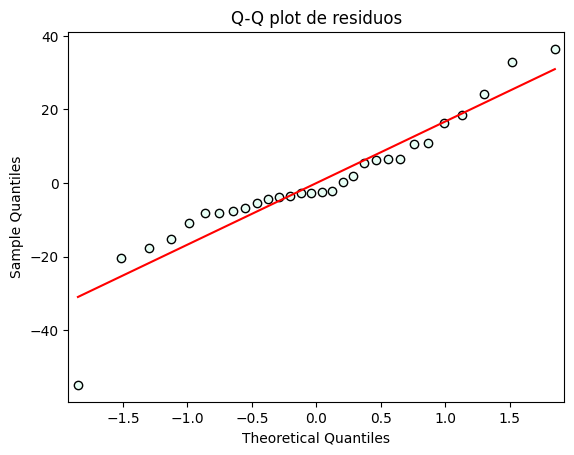

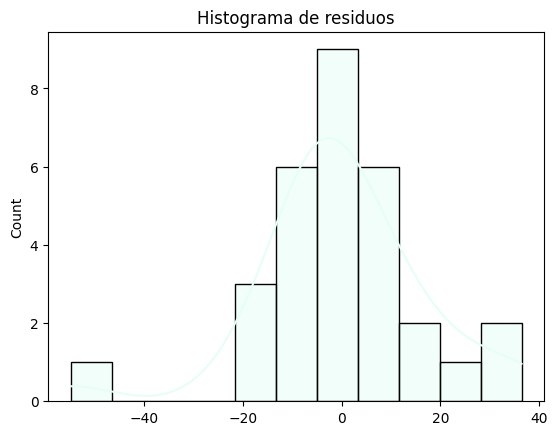

In [176]:
import statsmodels.api as sm

# Marielena Carvajal Becerra
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#E7FEF5',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#E7FEF5")
plt.title("Histograma de residuos")
plt.show()

In [177]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df["Dispositivo"] == "Laptop"]["Tiempo_Segundos"]
grupo_B = df[df["Dispositivo"] == "Celular"]["Tiempo_Segundos"]
grupo_C = df[df["Dispositivo"] == "Tablet"]["Tiempo_Segundos"]

stat, p = levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9267
p-valor: 0.4081


Lambda óptimo: -0.2616658889508786


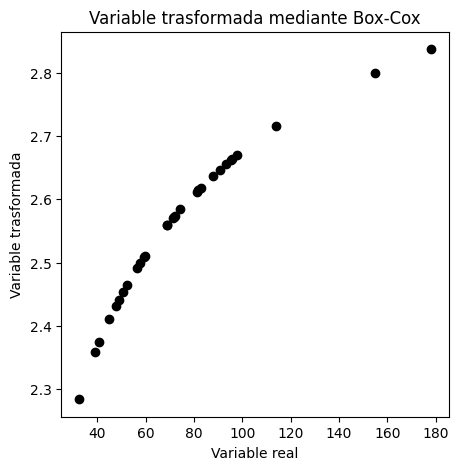

In [178]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["Tiempo_Segundos_boxcox"], lambda_opt = boxcox(df["Tiempo_Segundos"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Tiempo_Segundos"], df["Tiempo_Segundos_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [179]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Tiempo_Segundos_boxcox ~ C(Dispositivo) + C(Participante)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Dispositivo),0.0142,2.0,1.1357,0.3432
C(Participante),0.3351,9.0,5.9644,0.0007
Residual,0.1124,18.0,NaN,NaN


In [180]:
residuales = modelo.resid

valor-p (Shapiro) = 0.726653446115195


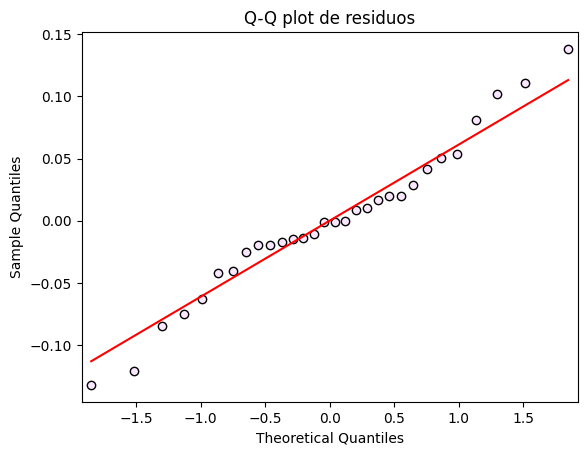

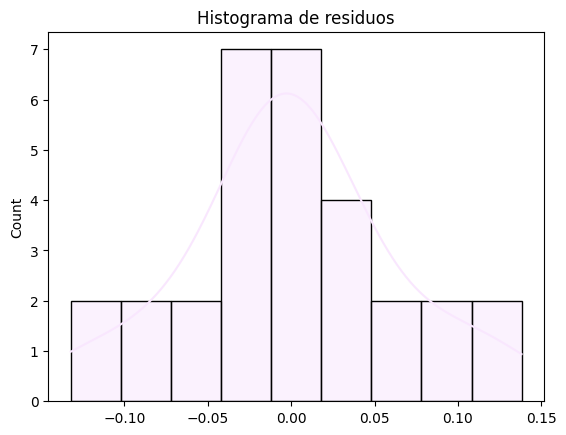

In [181]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s',
          markerfacecolor='#F9E7FE',markeredgecolor='black',)
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True,color="#F9E7FE")
plt.title("Histograma de residuos")
plt.show()

In [182]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df["Dispositivo"] == "Laptop"]["Tiempo_Segundos_boxcox"]
grupo_B = df[df["Dispositivo"] == "Celular"]["Tiempo_Segundos_boxcox"]
grupo_C = df[df["Dispositivo"] == "Tablet"]["Tiempo_Segundos_boxcox"]

stat, p = levene(grupo_A, grupo_B, grupo_C,)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.7468
p-valor: 0.4834


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Celular Laptop  -0.0427 0.7409 -0.1855    0.1  False
Celular Tablet   0.0062 0.9937 -0.1366 0.1489  False
 Laptop Tablet   0.0489 0.6762 -0.0939 0.1916  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

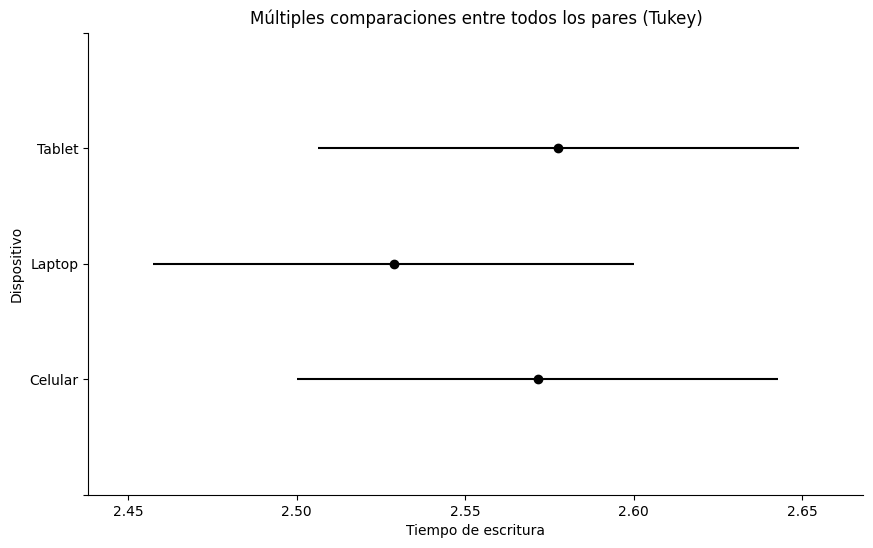

In [183]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Tiempo_Segundos_boxcox'], # Variable de respuesta
    groups=df['Dispositivo'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Dispositivo", xlabel="Tiempo de escritura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [184]:
# Calcular promedios de cada método

df.groupby(["Dispositivo"])["Tiempo_Segundos_boxcox"].mean()

,Tiempo_Segundos_boxcox
Dispositivo,
Celular,2.571451
Laptop,2.528727
Tablet,2.577615


In [185]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Dispositivo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.031


In [186]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Dispositivo"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.0307
f de Cohen = 0.1780
Potencia de la prueba = 0.1196


In [187]:
n_necesario = analisis_potencia.solve_power(
    effect_size=f_cohen,
    alpha=0.05,
    power=0.80,   # Potencia de la prueba
    k_groups=k_grupos
)

print(f"Observaciones totales necesarias: {n_necesario:.2f}")
print(f"Observaciones por grupo: {np.ceil(n_necesario / k_grupos):.0f}")

Observaciones totales necesarias: 307.07
Observaciones por grupo: 103
